## 2.3 Cart-pole balance

**(a)**

Starting from the continuous-time dynamics $\dot{s} = f(s, u)$, we apply **Euler integration** to get the discrete-time approximation:

$$s_{k+1} \approx s_k + \Delta t\, f(s_k, u_k).$$

We then **linearize** $f$ around the equilibrium $(\bar{s}, \bar{u})$ via a first-order Taylor expansion:

$$f(s_k, u_k) \approx f(\bar{s}, \bar{u}) + \frac{\partial f}{\partial s}\bigg|_{(\bar{s},\bar{u})}(s_k - \bar{s}) + \frac{\partial f}{\partial u}\bigg|_{(\bar{s},\bar{u})}(u_k - \bar{u}).$$

Since $(\bar{s}, \bar{u})$ is an equilibrium, $f(\bar{s}, \bar{u}) = 0$, and $\bar{u} = 0$. Defining $\tilde{s}_k = s_k - \bar{s}$ and subtracting $\bar{s}$ from both sides:

$$\tilde{s}_{k+1} \approx \tilde{s}_k + \Delta t\left(\frac{\partial f}{\partial s}\bigg|_{(\bar{s},\bar{u})}\tilde{s}_k + \frac{\partial f}{\partial u}\bigg|_{(\bar{s},\bar{u})}u_k\right) = \underbrace{\left(I + \Delta t\,\frac{\partial f}{\partial s}\bigg|_{(\bar{s},\bar{u})}\right)}_{A}\tilde{s}_k + \underbrace{\Delta t\,\frac{\partial f}{\partial u}\bigg|_{(\bar{s},\bar{u})}}_{B}u_k.$$

Substituting the given Jacobians evaluated at $\bar{s} = (0,\pi,0,0)$, $\bar{u}=0$:

$$A = I_4 + \Delta t \begin{bmatrix}0&0&1&0\\0&0&0&1\\0&\frac{m_p g}{m_c}&0&0\\0&\frac{(m_c+m_p)g}{m_c \ell}&0&0\end{bmatrix}, \qquad B = \Delta t \begin{bmatrix}0\\0\\\frac{1}{m_c}\\\frac{1}{m_c\ell}\end{bmatrix}.$$

**(b)**

In [1]:
import numpy as np
from cartpole_balance import compute_lti_matrices, ricatti_recursion

A, B = compute_lti_matrices()
Q, R = np.eye(4), np.eye(1)
K = ricatti_recursion(A, B, Q, R)
print("K_inf:\n", np.round(K, 2))

K: [[   0.7291397  -231.85419273    4.21967187  -68.24742822]]
K_inf:
 [[   0.73 -231.85    4.22  -68.25]]


**(c)**

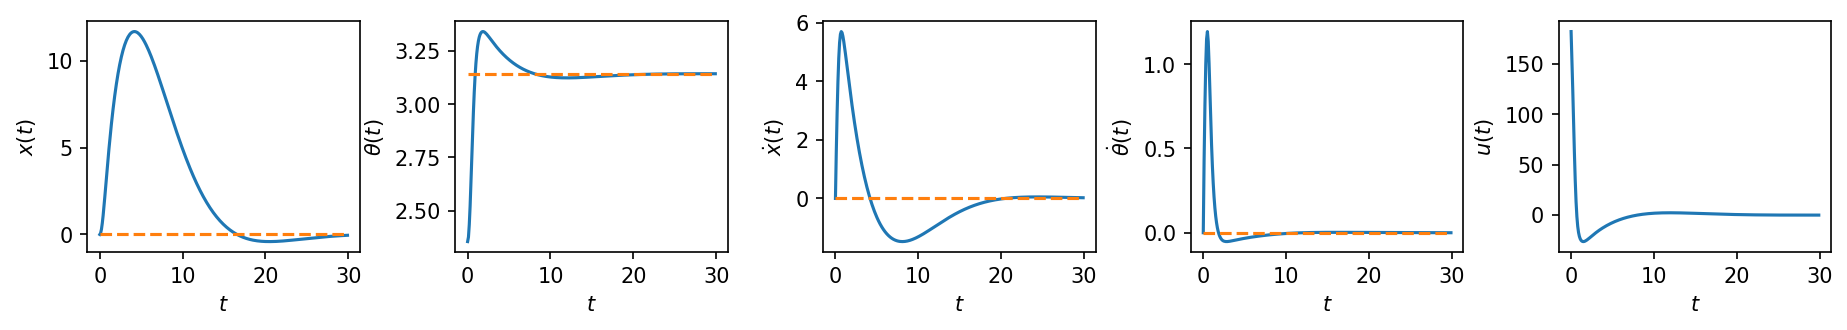

In [2]:
from cartpole_balance import simulate, plot_state_and_control_history

t = np.arange(0.0, 30.0, 0.1)
s_ref = np.array([0.0, np.pi, 0.0, 0.0]) * np.ones((t.size, 1))
u_ref = np.array([0.0])
s0 = np.array([0.0, 3 * np.pi / 4, 0.0, 0.0])
s, u = simulate(t, s_ref, u_ref, s0, K)
plot_state_and_control_history(s, u, t, s_ref, "cartpole_balance")

In [3]:
from animations import animate_cartpole
from IPython.display import HTML
import matplotlib.pyplot as plt

fig, ani = animate_cartpole(t, s[:, 0], s[:, 1])
plt.close(fig)
HTML(ani.to_jshtml())

**(d)**

**(i)** The Jacobians $\frac{\partial f}{\partial s}$ and $\frac{\partial f}{\partial u}$ do not depend on the cart position $x$ — only on $\theta$, $\dot{\theta}$, and $u$. Since the reference trajectory always maintains $\bar{\theta}(t) = \pi$, $\dot{\bar{\theta}}(t) = 0$, and $\bar{u} = 0$, the linearization point is identical at every time step regardless of the time-varying $\bar{x}(t)$. Therefore $A$ and $B$ are constant and do not need to be recomputed.

**(iii)** The desired trajectory $\bar{x}(t) = a\sin(2\pi t/T)$ requires the cart to accelerate ($\ddot{\bar{x}} \neq 0$), which physically means a nonzero reference force $\bar{u}(t) \neq 0$ is needed to drive it. The LQR was designed assuming $\bar{u} = 0$, so there is no feedforward term to generate this force. As a result the controller cannot simultaneously track $\bar{x}(t)$ and keep $\theta = \pi$: the cart acceleration perturbs the pendulum, causing $\theta$ and $\dot{\theta}$ to oscillate. Increasing $Q$ tightens regulation around the reference but does not fix the missing feedforward, so $\theta$ and $\dot{\theta}$ keep oscillating.

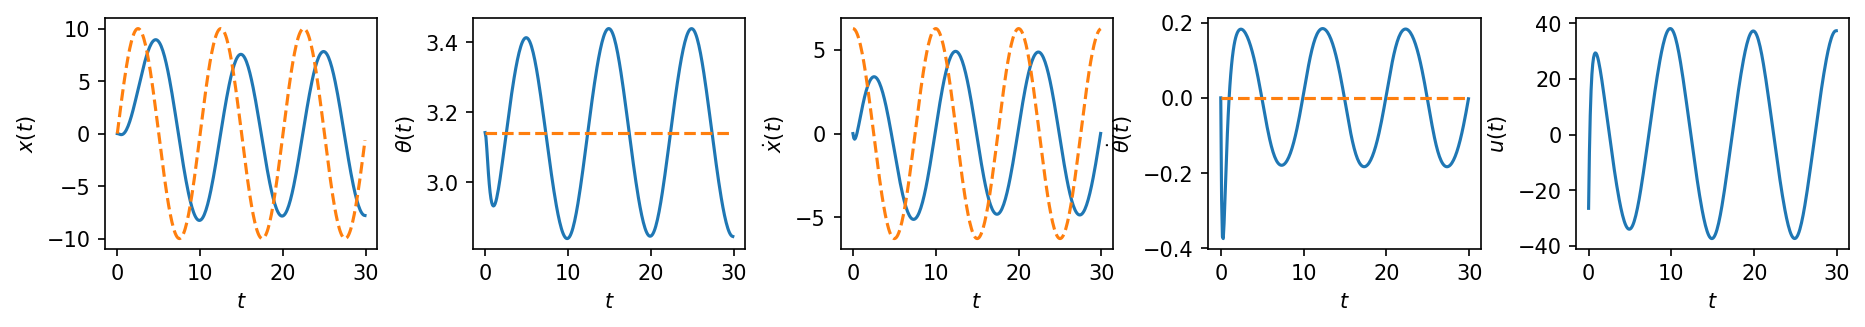

In [4]:
from cartpole_balance import simulate, reference, plot_state_and_control_history

t = np.arange(0.0, 30.0, 0.1)
s_ref = np.array([reference(ti) for ti in t])
u_ref = np.array([0.0])
s0 = np.array([0.0, np.pi, 0.0, 0.0])
s, u = simulate(t, s_ref, u_ref, s0, K)
plot_state_and_control_history(s, u, t, s_ref, "cartpole_balance_tv")

In [5]:
from animations import animate_cartpole
from IPython.display import HTML
import matplotlib.pyplot as plt

fig, ani = animate_cartpole(t, s[:, 0], s[:, 1])
plt.close(fig)
HTML(ani.to_jshtml())